## 1. Import Libraries

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 47.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math


from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.inspection import permutation_importance




##2. Load the data

In [3]:
df = pd.read_csv("/content/real_drug_solubility_esol.csv")

##3. Data Understanding


In [4]:
print(f"This is the dataset for Drug Solubility")
print(f'It has {df.shape[0]} rows and {df.shape[1]} columns')
print(f"The columns are: \n{', '.join(df.columns)}\n")

print(f"Data Types")
print(df.dtypes)

print(f"\nFirst five rows")
print(df.head())

stat_summary = df.describe(include=[np.int64,np.float64])

print(f"\nThe summary statistics are: \n{stat_summary}")

This is the dataset for Drug Solubility
It has 1128 rows and 3 columns
The columns are: 
compound_name, logS_solubility, SMILES

Data Types
compound_name       object
logS_solubility    float64
SMILES              object
dtype: object

First five rows
  compound_name  logS_solubility  \
0     Amigdalin            -0.77   
1      Fenfuram            -3.30   
2        citral            -2.06   
3        Picene            -7.87   
4     Thiophene            -1.33   

                                              SMILES  
0  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...  
1                             Cc1occc1C(=O)Nc2ccccc2  
2                               CC(C)=CCCC(C)=CC(=O)  
3                 c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43  
4                                            c1ccsc1  

The summary statistics are: 
       logS_solubility
count      1128.000000
mean         -3.050102
std           2.096441
min         -11.600000
25%          -4.317500
50%          -2.860000
75%       

##4. Data Quality Check

In [5]:
missing_values = df.isnull().sum()
print(f"The dataset has {missing_values.sum()} missing values\n")

duplicates = df.duplicated().sum()
print(f"The dataset has {duplicates} duplicate values\n")


The dataset has 0 missing values

The dataset has 0 duplicate values



## 5. Preprocessing of data

### Identify identical molecules

In [6]:
def canonical_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return Chem.MolToSmiles(mol)



In [7]:
df['Canonical_SMILES'] = [canonical_smiles(mol) for mol in df['SMILES']]
failed = df.loc[df['Canonical_SMILES'].isna(), 'compound_name'].tolist()
assert len(failed) == 0, f"{len(failed)} SMILES failed to parse: {failed}"


In [8]:
df.head()

,compound_name,logS_solubility,SMILES,Canonical_SMILES
0,Amigdalin,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,N#CC(OC1OC(COC2OC(CO)C(O)C(O)C2O)C(O)C(O)C1O)c...
1,Fenfuram,-3.30,Cc1occc1C(=O)Nc2ccccc2,Cc1occc1C(=O)Nc1ccccc1
2,citral,-2.06,CC(C)=CCCC(C)=CC(=O),CC(C)=CCCC(C)=CC=O
3,Picene,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,c1ccc2c(c1)ccc1c2ccc2c3ccccc3ccc21
4,Thiophene,-1.33,c1ccsc1,c1ccsc1


In [9]:
def descriptors_mol(smiles):

    descriptors = []

    for smi in smiles:

        mol = Chem.MolFromSmiles(smi)

        if mol is None:
            descriptors.append([np.nan] * 18)
            continue

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_MolMR = Descriptors.MolMR(mol)
        desc_HeavyAtomCount = Descriptors.HeavyAtomCount(mol)

        desc_NumHAcceptors = Descriptors.NumHAcceptors(mol)
        desc_NumHDonors = Descriptors.NumHDonors(mol)
        desc_NumHeteroatoms = Descriptors.NumHeteroatoms(mol)

        desc_NumRotatableBonds = Descriptors.NumRotatableBonds(mol)
        desc_NumValenceElectrons = Descriptors.NumValenceElectrons(mol)

        desc_NumAromaticRings = Descriptors.NumAromaticRings(mol)
        desc_NumSaturatedRings = Descriptors.NumSaturatedRings(mol)
        desc_NumAliphaticRings = Descriptors.NumAliphaticRings(mol)
        desc_RingCount = Descriptors.RingCount(mol)

        desc_TPSA = Descriptors.TPSA(mol)
        desc_LabuteASA = Descriptors.LabuteASA(mol)
        desc_BalabanJ = Descriptors.BalabanJ(mol)
        desc_BertzCT = Descriptors.BertzCT(mol)

        desc_FractionCSP3 = Descriptors.FractionCSP3(mol)

        row = [
            desc_MolWt,
            desc_MolLogP,
            desc_MolMR,
            desc_HeavyAtomCount,
            desc_NumHAcceptors,
            desc_NumHDonors,
            desc_NumHeteroatoms,
            desc_NumRotatableBonds,
            desc_NumValenceElectrons,
            desc_NumAromaticRings,
            desc_NumSaturatedRings,
            desc_NumAliphaticRings,
            desc_RingCount,
            desc_TPSA,
            desc_LabuteASA,
            desc_BalabanJ,
            desc_BertzCT,
            desc_FractionCSP3
        ]

        descriptors.append(row)

    columnNames = [
        "MolWt",
        "MolLogP",
        "MolMR",
        "HeavyAtomCount",
        "NumHAcceptors",
        "NumHDonors",
        "NumHeteroatoms",
        "NumRotatableBonds",
        "NumValenceElectrons",
        "NumAromaticRings",
        "NumSaturatedRings",
        "NumAliphaticRings",
        "RingCount",
        "TPSA",
        "LabuteASA",
        "BalabanJ",
        "BertzCT",
        "FractionCSP3"
    ]

    return pd.DataFrame(
        descriptors,
        columns=columnNames
    )

In [10]:
descriptor_df = descriptors_mol(df['Canonical_SMILES'])

### Understanding Descriptor dataset

In [11]:
print(f"This is the dataset for Drug Solubility with Descriptors")
print(f'It has {descriptor_df.shape[0]} rows and {descriptor_df.shape[1]} columns')
print(f"The columns are: \n{', '.join(descriptor_df.columns)}\n")

print(f"Data Types")
print(descriptor_df.dtypes)

print(f"\nFirst five rows")
print(descriptor_df.head())


This is the dataset for Drug Solubility with Descriptors
It has 1128 rows and 18 columns
The columns are: 
MolWt, MolLogP, MolMR, HeavyAtomCount, NumHAcceptors, NumHDonors, NumHeteroatoms, NumRotatableBonds, NumValenceElectrons, NumAromaticRings, NumSaturatedRings, NumAliphaticRings, RingCount, TPSA, LabuteASA, BalabanJ, BertzCT, FractionCSP3

Data Types
MolWt                  float64
MolLogP                float64
MolMR                  float64
HeavyAtomCount           int64
NumHAcceptors            int64
NumHDonors               int64
NumHeteroatoms           int64
NumRotatableBonds        int64
NumValenceElectrons      int64
NumAromaticRings         int64
NumSaturatedRings        int64
NumAliphaticRings        int64
RingCount                int64
TPSA                   float64
LabuteASA              float64
BalabanJ               float64
BertzCT                float64
FractionCSP3           float64
dtype: object

First five rows
     MolWt  MolLogP     MolMR  HeavyAtomCount  NumHAcc

In [12]:
descriptor_df.isnull().sum()

,0
MolWt,0
MolLogP,0
MolMR,0
HeavyAtomCount,0
NumHAcceptors,0
NumHDonors,0
NumHeteroatoms,0
NumRotatableBonds,0
NumValenceElectrons,0
NumAromaticRings,0


In [13]:
constant_features = descriptor_df.columns[
    descriptor_df.nunique() <= 1
]

constant_features

Index([], dtype='object')

### DataSet for Machine Learning

In [14]:
df_new = pd.concat(
    [
        df.reset_index(drop=True),
        descriptor_df.reset_index(drop=True)
    ],
    axis=1
)

In [15]:
duplicates = df_new[df_new['Canonical_SMILES'].duplicated(keep=False)].sort_values('Canonical_SMILES')
duplicates[['compound_name', 'Canonical_SMILES', 'logS_solubility']]

,compound_name,Canonical_SMILES,logS_solubility
222,2-bromonaphthalene,Brc1ccc2ccccc2c1,-4.400
554,2-Bromonapthalene,Brc1ccc2ccccc2c1,-4.400
213,eucalyptol,CC12CCC(CC1)C(C)(C)O2,-1.640
976,"1,8-Cineole",CC12CCC(CC1)C(C)(C)O2,-1.740
232,Epiandrosterone,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,-4.160
655,Androsterone,CC12CCC3C(CCC4CC(O)CCC43C)C1CCC2=O,-4.402
825,5-Ethyl-5-isopropylbarbituric acid,CCC1(C(C)C)C(=O)NC(=O)NC1=O,-2.148
701,probarbital,CCC1(C(C)C)C(=O)NC(=O)NC1=O,-2.210
147,Amobarbital,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,-2.468
779,5-Ethyl-5-(3-methylbutyl)barbital,CCC1(CCC(C)C)C(=O)NC(=O)NC1=O,-2.658


In [16]:
disagreement = duplicates.groupby('Canonical_SMILES')['logS_solubility'].nunique()
print(f"{(disagreement > 1).sum()} duplicate groups have conflicting solubility values")

df_clean = df_new.drop_duplicates(subset='Canonical_SMILES', keep='first').reset_index(drop=True)
assert df_clean['Canonical_SMILES'].duplicated().sum() == 0

6 duplicate groups have conflicting solubility values


In [17]:
df_clean.shape

(1117, 22)

## EDA

### Distributions Analysis of Features

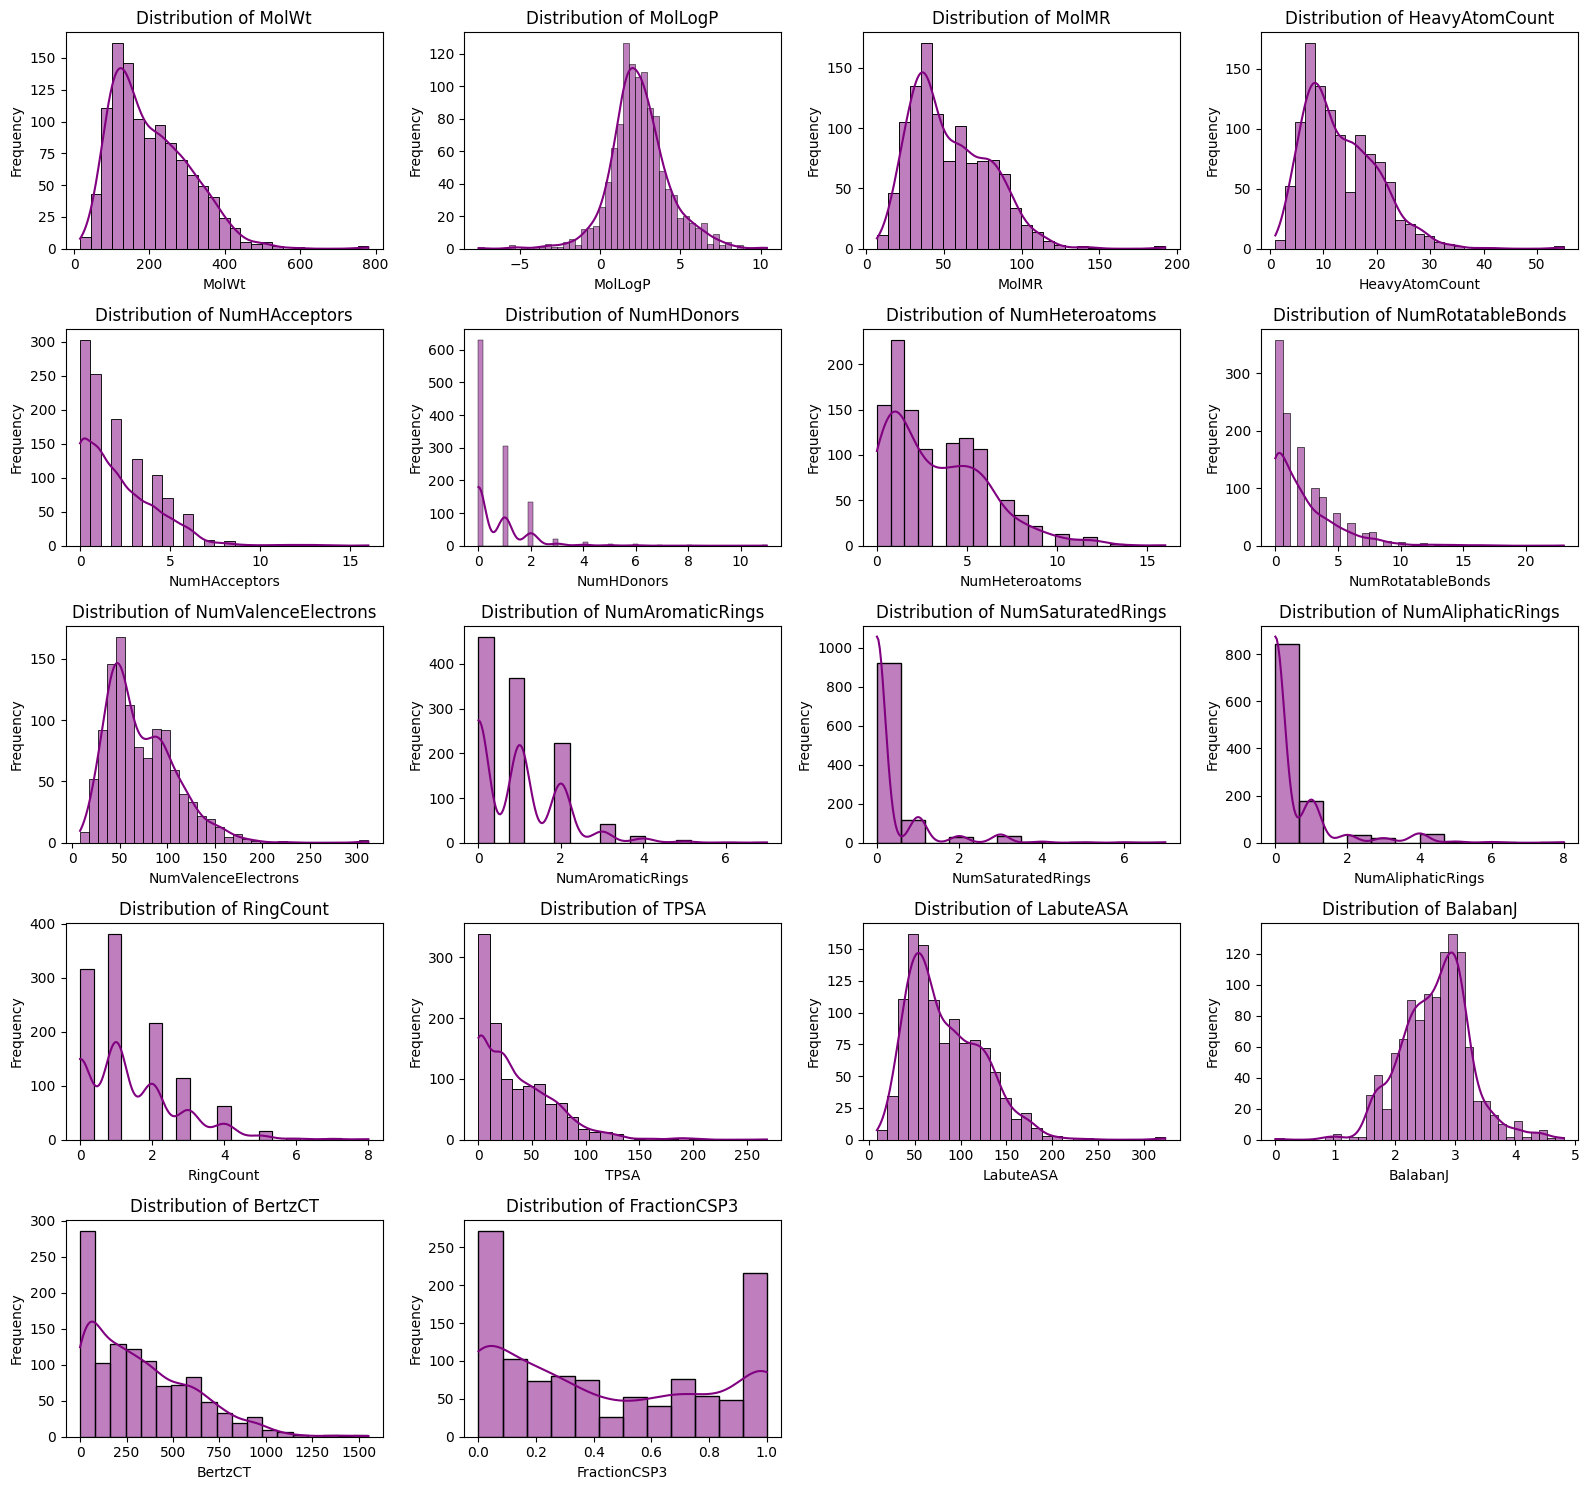

In [18]:
numeric_columns = df_clean.select_dtypes(include=[np.number]).columns
numeric_columns = numeric_columns.drop('logS_solubility')

n_cols = 4
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.histplot(df_clean[col], color='Purple', kde=True, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {col}')

for i in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()



### Outlier Analysis with BoxPlot

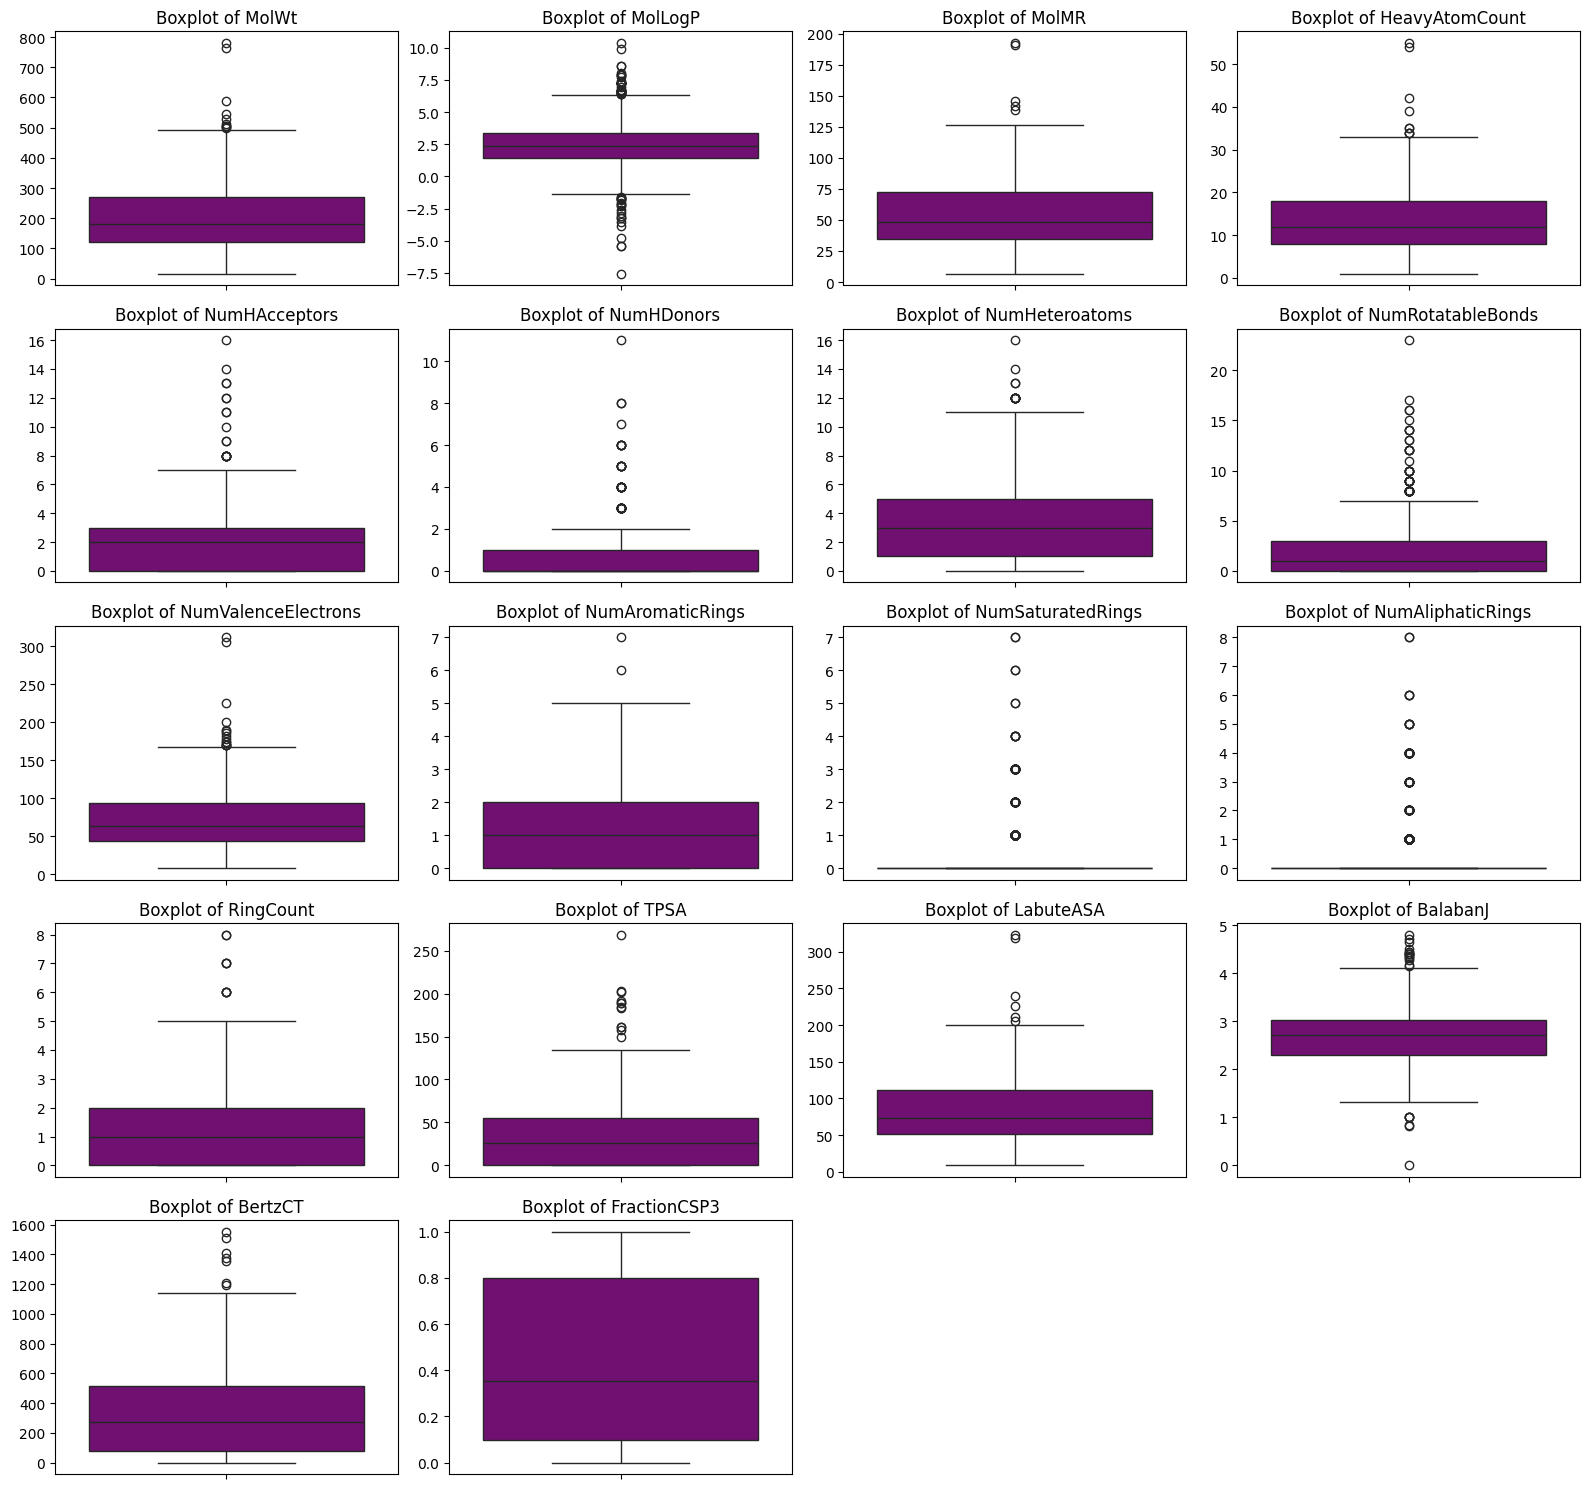

In [19]:
n_cols = 4
n_rows = math.ceil(len(numeric_columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 3))
axes = axes.flatten()
for i, column in enumerate(numeric_columns):
    sns.boxplot(y=df_clean[column], ax=axes[i], color='Purple')
    axes[i].set_title(f"Boxplot of {column}")
    axes[i].set_ylabel("")
    axes[i].set_xlabel("")

for j in range(len(numeric_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Analysis

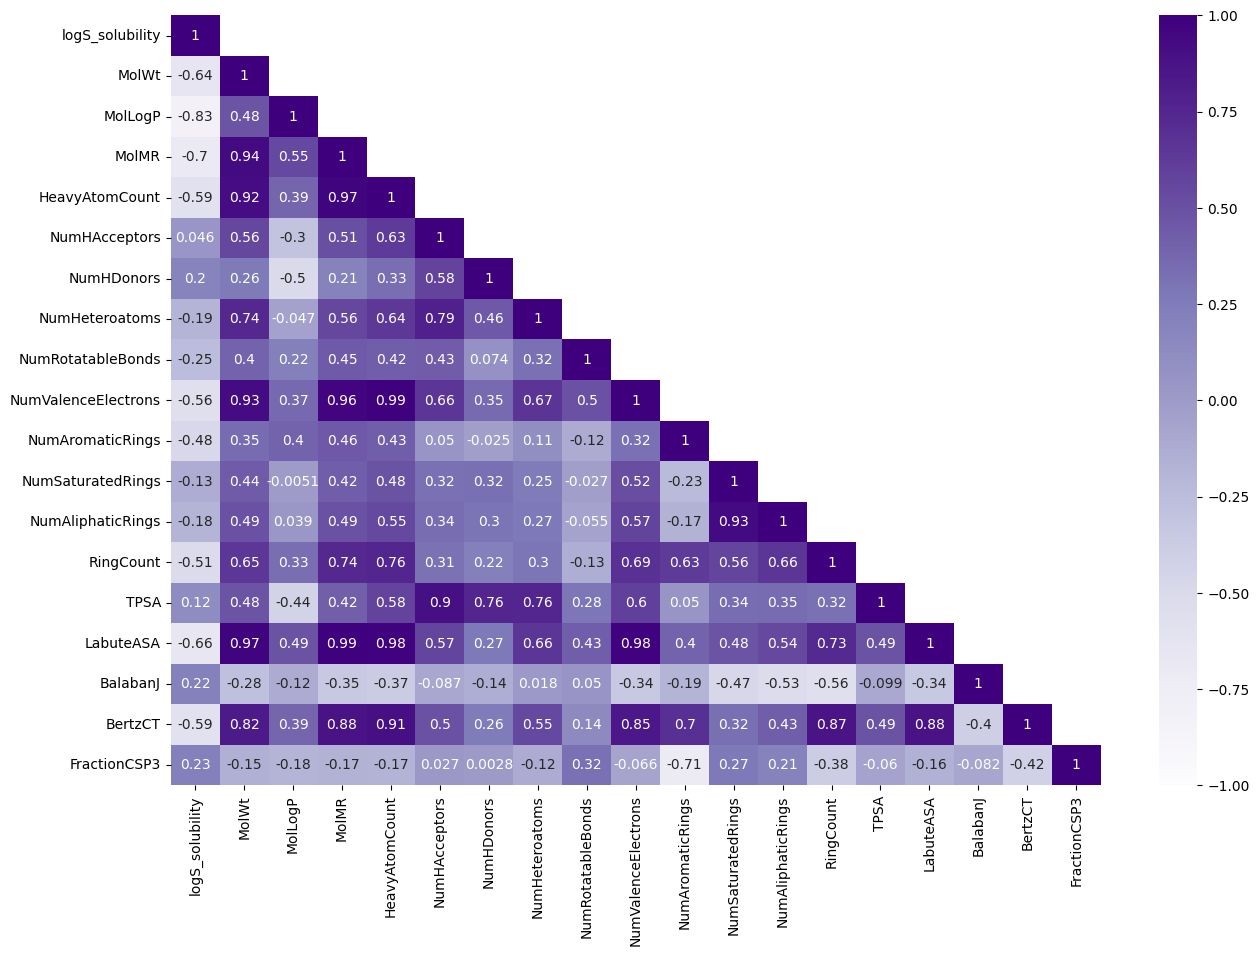


Features most correlated with Solubility:
MolLogP               -0.827
MolMR                 -0.699
LabuteASA             -0.655
MolWt                 -0.639
BertzCT               -0.589
HeavyAtomCount        -0.586
NumValenceElectrons   -0.556
RingCount             -0.513
NumAromaticRings      -0.483
NumRotatableBonds     -0.245
FractionCSP3           0.226
BalabanJ               0.216
NumHDonors             0.201
NumHeteroatoms        -0.186
NumAliphaticRings     -0.182
NumSaturatedRings     -0.128
TPSA                   0.117
NumHAcceptors          0.046
Name: logS_solubility, dtype: float64


In [20]:
cols_to_corr = ['logS_solubility'] + list(numeric_columns)
corr = df_clean[cols_to_corr].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='Purples', vmax=1, vmin=-1, mask=np.triu(np.ones_like(corr, dtype=bool), k=1))
plt.show()

print("\nFeatures most correlated with Solubility:")
print(corr["logS_solubility"].drop("logS_solubility").sort_values(key=np.abs, ascending=False).round(3))

### Target Distribution

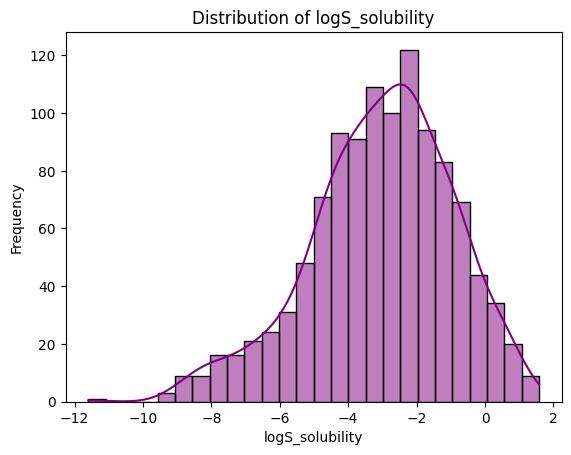

In [21]:
sns.histplot(df_clean['logS_solubility'], color='purple', kde=True)
plt.xlabel('logS_solubility')
plt.ylabel('Frequency')
plt.title('Distribution of logS_solubility')
plt.show()

## Scaffold-Based Data Splitting

Random train-test splitting can place structurally similar molecules in both
training and test sets. This can lead to optimistic estimates of model
generalization.

To obtain a more challenging and chemically meaningful evaluation, molecules
are divided according to their Bemis-Murcko scaffolds.

Molecules sharing the same scaffold are kept within the same data partition,
ensuring that the test set contains chemical scaffolds not seen during model
training.

In [22]:
def get_murcko_scaffold(smiles):
    """
    Generate the Bemis-Murcko scaffold from a SMILES string.
    Returns None if the molecule cannot be parsed.
    """

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

    return scaffold


df_clean["Murcko_Scaffold"] = (
    df_clean["Canonical_SMILES"]
    .apply(get_murcko_scaffold)
)

In [23]:
print("Number of molecules:", len(df_clean))
print("Number of unique Murcko scaffolds:",
      df_clean["Murcko_Scaffold"].nunique())

print(
    "Molecules without a scaffold:",
    df_clean["Murcko_Scaffold"].isna().sum()
)

Number of molecules: 1117
Number of unique Murcko scaffolds: 269
Molecules without a scaffold: 0


In [24]:
scaffold_counts = (
    df_clean["Murcko_Scaffold"]
    .value_counts()
)

print("Total unique scaffolds:",
      scaffold_counts.shape[0])

print("\nTop 10 most frequent scaffolds:")
print(scaffold_counts.head(10))

Total unique scaffolds: 269

Top 10 most frequent scaffolds:
Murcko_Scaffold
                                316
c1ccccc1                        253
c1ccc(-c2ccccc2)cc1              39
c1ccc2ccccc2c1                   21
O=C1CC(=O)NC(=O)N1               19
O=C1C=C2CCC3C4CCCC4CCC3C2CC1     17
c1ncncn1                         16
c1ccncc1                         14
c1ccc(Cc2ccccc2)cc1              11
C1CCCCC1                         10
Name: count, dtype: int64


In [25]:
print(
    "\nScaffolds represented by only one molecule:",
    (scaffold_counts == 1).sum()
)


Scaffolds represented by only one molecule: 197


In [26]:
from sklearn.model_selection import train_test_split

unique_scaffolds = df_clean["Murcko_Scaffold"].unique()

train_scaffolds, test_scaffolds = train_test_split(
    unique_scaffolds,
    test_size=0.20,
    random_state=42
)

train_scaffold_df = df_clean[
    df_clean["Murcko_Scaffold"].isin(train_scaffolds)
].copy()

test_scaffold_df = df_clean[
    df_clean["Murcko_Scaffold"].isin(test_scaffolds)
].copy()

In [27]:
train_scaffold_set = set(train_scaffolds)
test_scaffold_set = set(test_scaffolds)

overlap = train_scaffold_set.intersection(test_scaffold_set)

print("Number of overlapping scaffolds:", len(overlap))

assert len(overlap) == 0, \
    "Scaffold leakage detected!"

Number of overlapping scaffolds: 0


In [28]:
print("Scaffold split:")
print("----------------")

print(f"Total molecules : {len(df_clean)}")
print(f"Training set    : {len(train_scaffold_df)}")
print(f"Test set        : {len(test_scaffold_df)}")

print("\nTraining fraction:",
      len(train_scaffold_df) / len(df_clean))

print("Test fraction:",
      len(test_scaffold_df) / len(df_clean))

print("\nUnique training scaffolds:",
      train_scaffold_df["Murcko_Scaffold"].nunique())

print("Unique test scaffolds:",
      test_scaffold_df["Murcko_Scaffold"].nunique())

Scaffold split:
----------------
Total molecules : 1117
Training set    : 985
Test set        : 132

Training fraction: 0.8818263205013429
Test fraction: 0.11817367949865712

Unique training scaffolds: 215
Unique test scaffolds: 54


In [29]:
X_train_scaffold = train_scaffold_df[numeric_columns]
y_train_scaffold = train_scaffold_df["logS_solubility"]

X_test_scaffold = test_scaffold_df[numeric_columns]
y_test_scaffold = test_scaffold_df["logS_solubility"]

In [30]:
X = df_clean[numeric_columns]
y = df_clean['logS_solubility']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (893, 18)
Test set:     (224, 18)


In [31]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"]

models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}



def cv_summarize(name, model, X_train, y_train,cv, scoring):
    cv_model = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring)
    mae = -cv_model["test_neg_mean_absolute_error"]
    rmse = -cv_model["test_neg_root_mean_squared_error"]
    r2 = cv_model["test_r2"]

    return {
        "Model": name,
        "MAE_mean": mae.mean(), "MAE_std": mae.std(),
        "RMSE_mean": rmse.mean(), "RMSE_std": rmse.std(),
        "R2_mean": r2.mean(), "R2_std": r2.std(),}

baseline_cv_results = pd.DataFrame(
    [cv_summarize(name, model, X_train, y_train, kfold, scoring)
     for name, model in models.items()]
)

display(baseline_cv_results.round(4))


,Model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,Dummy (mean),1.6721,0.0795,2.1012,0.1315,-0.0080,0.0051
1,Linear Regression,0.7512,0.0458,0.9601,0.0718,0.7867,0.0348
2,Random Forest,0.5110,0.0309,0.7101,0.0623,0.8845,0.0136
3,Gradient Boosting,0.5374,0.0269,0.7255,0.0562,0.8795,0.0119


In [32]:
param_grid = {
    "max_features": ["sqrt", 0.33, 1.0],
    "min_samples_leaf": [1, 2, 5],
    "n_estimators": [300],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Best params (base):", grid.best_params_)
rf_tuned = grid.best_estimator_



Best params (base): {'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}


In [33]:
rf_final = grid.best_estimator_
rf_final.fit(X_train, y_train)
y_pred_rf = rf_final.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred_rf)
final_rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
final_r2 = r2_score(y_test, y_pred_rf)

final_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [final_mae, final_rmse, final_r2],
})
display(final_results.round(4))

,Metric,Value
0,MAE,0.4755
1,RMSE,0.6967
2,R²,0.8854


In [34]:
rf_scaffold = grid.best_estimator_

rf_scaffold.fit(
    X_train_scaffold,
    y_train_scaffold
)

y_pred_scaffold = rf_scaffold.predict(X_test_scaffold)

mae_scaffold = mean_absolute_error(
    y_test_scaffold,
    y_pred_scaffold
)

rmse_scaffold = np.sqrt(
    mean_squared_error(
        y_test_scaffold,
        y_pred_scaffold
    )
)

r2_scaffold = r2_score(
    y_test_scaffold,
    y_pred_scaffold
)

print("Scaffold Split Performance")
print("--------------------------")
print(f"MAE  : {mae_scaffold:.4f}")
print(f"RMSE : {rmse_scaffold:.4f}")
print(f"R²   : {r2_scaffold:.4f}")

Scaffold Split Performance
--------------------------
MAE  : 0.6862
RMSE : 0.9548
R²   : 0.8523


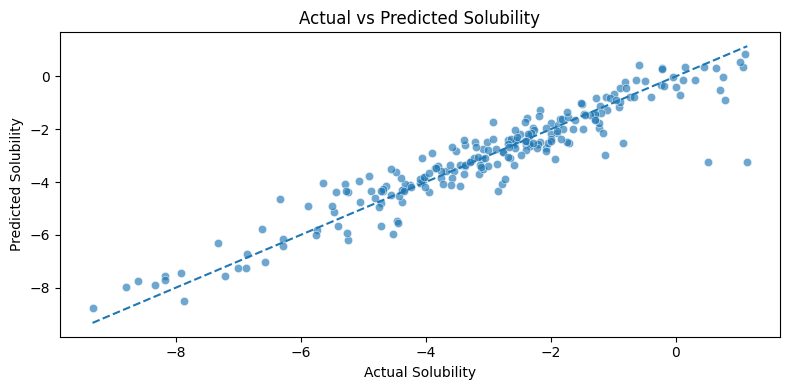

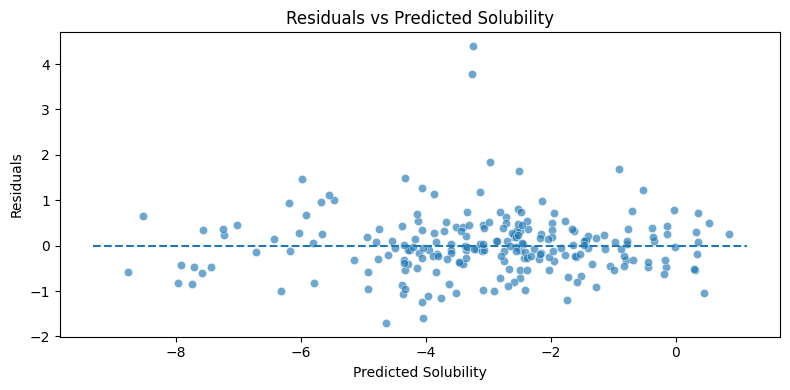

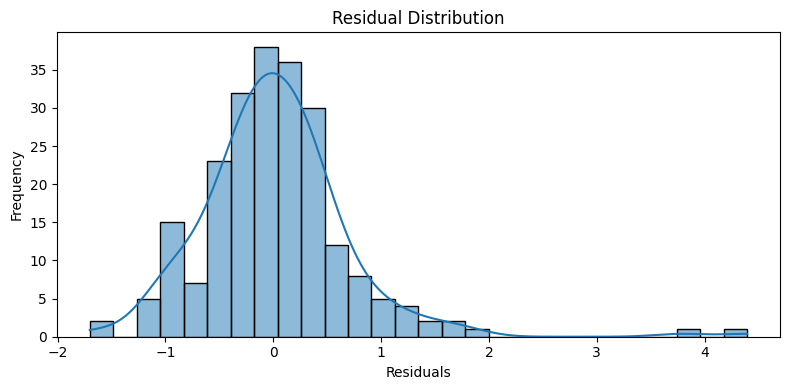

In [35]:
residuals = y_test - y_pred_rf

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(x=y_test, y=y_pred_rf, ax=ax, alpha=0.65)
min_q = min(y_test.min(), y_pred_rf.min())
max_q = max(y_test.max(), y_pred_rf.max())
ax.plot([min_q, max_q], [min_q, max_q], linestyle="--")
ax.set_title("Actual vs Predicted Solubility")
ax.set_xlabel("Actual Solubility")
ax.set_ylabel("Predicted Solubility")
plt.tight_layout()
plt.show()
print()

fig, ax = plt.subplots(figsize=(8, 4))
sns.scatterplot(x=y_pred_rf, y=residuals, ax=ax, alpha=0.65)
ax.plot([min_q, max_q], [0, 0], linestyle="--")
ax.set_title("Residuals vs Predicted Solubility")
ax.set_xlabel("Predicted Solubility")
ax.set_ylabel("Residuals")
plt.tight_layout()
plt.show()
print()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(residuals, kde=True, ax=ax)
ax.set_title("Residual Distribution")
ax.set_xlabel("Residuals")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()


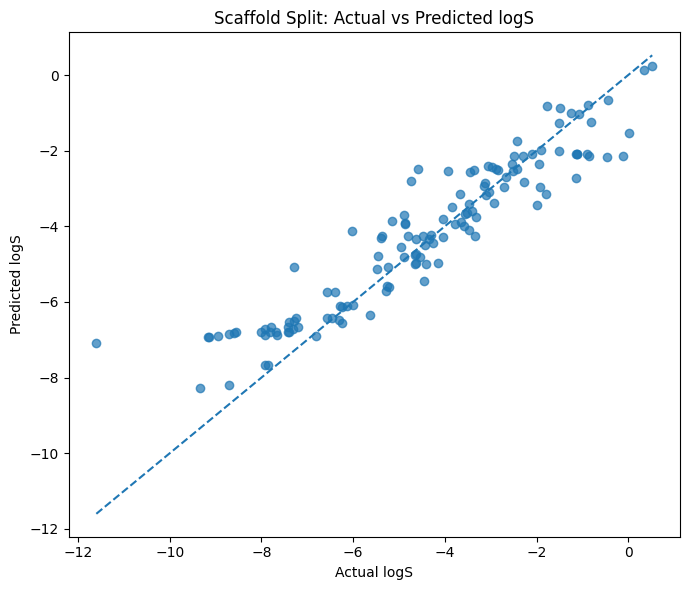

In [36]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_scaffold,
    y_pred_scaffold,
    alpha=0.7
)

min_value = min(
    y_test_scaffold.min(),
    y_pred_scaffold.min()
)

max_value = max(
    y_test_scaffold.max(),
    y_pred_scaffold.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual logS")
plt.ylabel("Predicted logS")
plt.title("Scaffold Split: Actual vs Predicted logS")

plt.tight_layout()
plt.show()

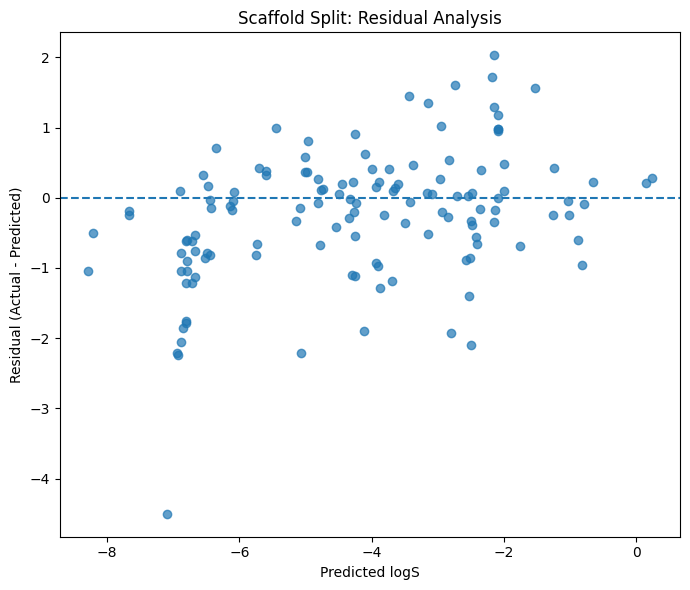

In [37]:
residuals_scaffold = (
    y_test_scaffold - y_pred_scaffold
)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_pred_scaffold,
    residuals_scaffold,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted logS")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Scaffold Split: Residual Analysis")

plt.tight_layout()
plt.show()

In [38]:
comparison = pd.DataFrame({
    "Evaluation": [
        "Random Split",
        "Scaffold Split"
    ],
    "MAE": [
        final_mae,
        mae_scaffold
    ],
    "RMSE": [
        final_rmse,
        rmse_scaffold
    ],
    "R2": [
        final_r2,
        r2_scaffold
    ]
})

comparison

,Evaluation,MAE,RMSE,R2
0,Random Split,0.475524,0.696653,0.885414
1,Scaffold Split,0.686243,0.954804,0.852258


In [39]:
print("Training logS:")
print(y_train_scaffold.describe())

print("\nTest logS:")
print(y_test_scaffold.describe())

Training logS:
count    985.000000
mean      -2.860892
std        1.960817
min       -9.018000
25%       -4.114000
50%       -2.692000
75%       -1.490000
max        1.580000
Name: logS_solubility, dtype: float64

Test logS:
count    132.000000
mean      -4.463606
std        2.493522
min      -11.600000
25%       -6.296750
50%       -4.425000
75%       -2.639500
max        0.522000
Name: logS_solubility, dtype: float64


In [40]:
train_descriptor_summary = (
    X_train_scaffold.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

test_descriptor_summary = (
    X_test_scaffold.describe().T[
        ["mean", "std", "min", "max"]
    ]
)

train_descriptor_summary

,mean,std,min,max
MolWt,196.858947,101.293328,16.043000,780.949000
MolLogP,2.328378,1.685025,-7.571400,10.388600
MolMR,52.443651,25.340639,6.731000,192.610800
HeavyAtomCount,12.910660,6.992166,1.000000,55.000000
NumHAcceptors,2.079188,2.098156,0.000000,16.000000
NumHDonors,0.695431,1.088852,0.000000,11.000000
NumHeteroatoms,3.201015,2.765238,0.000000,16.000000
NumRotatableBonds,2.267005,2.719019,0.000000,23.000000
NumValenceElectrons,70.361421,36.848726,8.000000,312.000000
NumAromaticRings,0.848731,0.967175,0.000000,6.000000


,importance
MolLogP,0.2896
MolMR,0.1553
LabuteASA,0.1021
MolWt,0.0751
TPSA,0.0576
BertzCT,0.0519
NumValenceElectrons,0.0497
NumHAcceptors,0.0472
HeavyAtomCount,0.0433
NumHeteroatoms,0.0334


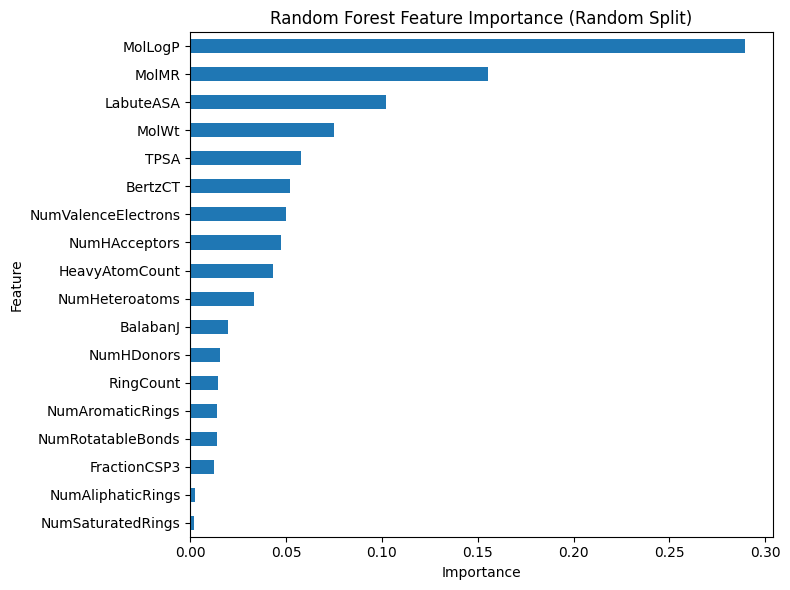

In [41]:
importance = pd.Series(
    rf_final.feature_importances_,
    index=X_train.columns,
).sort_values(ascending=True)

display(importance.sort_values(ascending=False).to_frame("importance").round(4))

print()
plt.figure(figsize=(8, 6))
importance.plot(kind="barh")
plt.title("Random Forest Feature Importance (Random Split)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Naive Physical Baseline (GSE-approximation)

The General Solubility Equation (Yalkowsky & Valvani, 1980) is:

    logS = 0.5 − 0.01×(MP − 25) − logP

ESOL/Delaney does not include melting point (MP), so the melting-point
term cannot be computed. We use a logP-only reduced form as an honest
approximation, evaluated with the SAME fixed coefficients as the
published equation (no fitting to our data) — this keeps it a true
"physics baseline," not a disguised linear regression.

    logS_GSE_approx = 0.5 − logP

In [42]:
gse_pred_test = 0.5 - X_test['MolLogP']

gse_mae  = mean_absolute_error(y_test, gse_pred_test)
gse_rmse = mean_squared_error(y_test, gse_pred_test) ** 0.5
gse_r2   = r2_score(y_test, gse_pred_test)

gse_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Value": [gse_mae, gse_rmse, gse_r2],
})
display(gse_results.round(4))

,Metric,Value
0,MAE,1.2971
1,RMSE,1.6643
2,R²,0.3460


## GSE Baseline on Scaffold Split

The GSE-approximation above was only evaluated on the random-split test set.
Since scaffold splitting is the more realistic, harder evaluation, we repeat
the GSE evaluation on `X_test_scaffold` so all three approaches
(GSE, RF random split, RF scaffold split) can be compared fairly.

In [43]:
gse_pred_scaffold = 0.5 - X_test_scaffold['MolLogP']

gse_mae_scaffold  = mean_absolute_error(y_test_scaffold, gse_pred_scaffold)
gse_rmse_scaffold = mean_squared_error(y_test_scaffold, gse_pred_scaffold) ** 0.5
gse_r2_scaffold   = r2_score(y_test_scaffold, gse_pred_scaffold)

full_comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "GSE_approx (Random Split)":   [gse_mae, gse_rmse, gse_r2],
    "GSE_approx (Scaffold Split)": [gse_mae_scaffold, gse_rmse_scaffold, gse_r2_scaffold],
    "Random Forest (Random Split)":   [final_mae, final_rmse, final_r2],
    "Random Forest (Scaffold Split)": [mae_scaffold, rmse_scaffold, r2_scaffold],
}).T
display(full_comparison.round(4))

rf_gain_random = (1 - final_rmse / gse_rmse) * 100
rf_gain_scaffold = (1 - rmse_scaffold / gse_rmse_scaffold) * 100
print(f"\nRF improvement over GSE, random split:   {rf_gain_random:.1f}%")
print(f"RF improvement over GSE, scaffold split: {rf_gain_scaffold:.1f}%")
print("\nIf the scaffold-split improvement is meaningfully smaller than the random-split")
print("improvement, this indicates part of RF's apparent edge over basic physics was")
print("coming from scaffold leakage rather than genuine structure-property learning.")

,0,1,2
Metric,MAE,RMSE,R²
GSE_approx (Random Split),1.297062,1.664344,0.345989
GSE_approx (Scaffold Split),1.591682,1.864219,0.43679
Random Forest (Random Split),0.475524,0.696653,0.885414
Random Forest (Scaffold Split),0.686243,0.954804,0.852258



RF improvement over GSE, random split:   58.1%
RF improvement over GSE, scaffold split: 48.8%

If the scaffold-split improvement is meaningfully smaller than the random-split
improvement, this indicates part of RF's apparent edge over basic physics was
coming from scaffold leakage rather than genuine structure-property learning.


## Scaffold-Aware Cross-Validation

The single scaffold split above gives one point estimate of scaffold-split
performance, with no sense of variance. If that particular split happened to
be easy or hard, we can't tell from one number alone.

`GroupKFold`, grouped by `Murcko_Scaffold`, repeats the scaffold-holdout
evaluation across 5 folds, giving a mean and standard deviation that can be
compared directly against the random-split CV results computed earlier.
This is the more defensible number to report as "true" generalization
performance, and lets us check whether the single-split scaffold R² above
was typical or an outlier.

In [46]:
from sklearn.model_selection import GroupKFold

group_kfold = GroupKFold(n_splits=5)
groups = df_clean["Murcko_Scaffold"]

X_full = df_clean[numeric_columns]
y_full = df_clean["logS_solubility"]

# sanity check: fold sizes shouldn't be wildly imbalanced given scaffold group sizes vary
fold_sizes = [len(test_idx) for _, test_idx in group_kfold.split(X_full, y_full, groups)]
print("Scaffold-CV fold sizes:", fold_sizes)
print(f"Min/Max fold size ratio: {min(fold_sizes)/max(fold_sizes):.2f}")

Scaffold-CV fold sizes: [316, 253, 183, 183, 182]
Min/Max fold size ratio: 0.58


In [47]:
scaffold_cv_results = cross_validate(
    rf_final,
    X_full, y_full,
    cv=group_kfold,
    groups=groups,
    scoring=["neg_mean_absolute_error", "neg_root_mean_squared_error", "r2"],
)

scaffold_cv_mae  = -scaffold_cv_results["test_neg_mean_absolute_error"]
scaffold_cv_rmse = -scaffold_cv_results["test_neg_root_mean_squared_error"]
scaffold_cv_r2   = scaffold_cv_results["test_r2"]

scaffold_cv_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R²"],
    "Mean": [scaffold_cv_mae.mean(), scaffold_cv_rmse.mean(), scaffold_cv_r2.mean()],
    "Std":  [scaffold_cv_mae.std(),  scaffold_cv_rmse.std(),  scaffold_cv_r2.std()],
})
display(scaffold_cv_summary.round(4))

,Metric,Mean,Std
0,MAE,0.6431,0.0452
1,RMSE,0.8534,0.0683
2,R²,0.7965,0.0361


In [48]:
# Compare scaffold-CV variance against random-split CV variance (from baseline_cv_results)
rf_random_cv = baseline_cv_results[baseline_cv_results["Model"] == "Random Forest"].iloc[0]

cv_variance_comparison = pd.DataFrame({
    "Split type": ["Random (5-fold CV)", "Scaffold (5-fold GroupKFold)"],
    "R2_mean": [rf_random_cv["R2_mean"], scaffold_cv_r2.mean()],
    "R2_std":  [rf_random_cv["R2_std"],  scaffold_cv_r2.std()],
})
display(cv_variance_comparison.round(4))

r2_drop = rf_random_cv["R2_mean"] - scaffold_cv_r2.mean()
combined_std = np.sqrt(rf_random_cv["R2_std"]**2 + scaffold_cv_r2.std()**2)
print(f"\nR² drop (random CV mean - scaffold CV mean): {r2_drop:.4f}")
print(f"Combined fold-to-fold std: {combined_std:.4f}")
if r2_drop > combined_std:
    print("The drop exceeds combined fold-to-fold noise — scaffold generalization")
    print("gap looks real, not just variance.")
else:
    print("The drop is within the range of fold-to-fold noise — evidence for a")
    print("genuine scaffold generalization gap is weak with this sample size.")

,Split type,R2_mean,R2_std
0,Random (5-fold CV),0.8845,0.0136
1,Scaffold (5-fold GroupKFold),0.7965,0.0361



R² drop (random CV mean - scaffold CV mean): 0.0880
Combined fold-to-fold std: 0.0386
The drop exceeds combined fold-to-fold noise — scaffold generalization
gap looks real, not just variance.


## Permutation Importance

Random Forest's built-in `feature_importances_` (computed above) is biased
toward high-cardinality/continuous features and can be misleading when
features are correlated. Permutation importance — measuring the drop in
test-set R² when a feature's values are randomly shuffled — is a more
reliable, model-agnostic alternative, and is computed here on the held-out
test set (not train) to avoid overfitting-inflated importance.

We compute it for both the random-split model and the scaffold-split model.
If the two rankings broadly agree, that's evidence the model is relying on
consistent, genuine structure-property relationships rather than
scaffold-specific memorization.

In [49]:

perm_random = permutation_importance(
    rf_final, X_test, y_test,
    n_repeats=30, random_state=42, scoring="r2", n_jobs=-1
)

perm_importance_random = pd.Series(
    perm_random.importances_mean, index=X_test.columns
).sort_values(ascending=False)

perm_importance_random_std = pd.Series(
    perm_random.importances_std, index=X_test.columns
)

print("Permutation importance (Random Split, test set):")
display(
    pd.DataFrame({
        "importance_mean": perm_importance_random,
        "importance_std": perm_importance_random_std[perm_importance_random.index],
    }).round(4)
)

Permutation importance (Random Split, test set):


,importance_mean,importance_std
MolLogP,0.3160,0.0239
MolMR,0.1178,0.0101
TPSA,0.0591,0.0052
LabuteASA,0.0591,0.0051
NumHAcceptors,0.0422,0.0050
MolWt,0.0363,0.0028
BertzCT,0.0247,0.0028
NumHeteroatoms,0.0244,0.0038
NumValenceElectrons,0.0191,0.0018
HeavyAtomCount,0.0147,0.0014


In [50]:
perm_scaffold = permutation_importance(
    rf_scaffold, X_test_scaffold, y_test_scaffold,
    n_repeats=30, random_state=42, scoring="r2", n_jobs=-1
)

perm_importance_scaffold = pd.Series(
    perm_scaffold.importances_mean, index=X_test_scaffold.columns
).sort_values(ascending=False)

print("Permutation importance (Scaffold Split, test set):")
display(perm_importance_scaffold.to_frame("importance_mean").round(4))

Permutation importance (Scaffold Split, test set):


,importance_mean
MolLogP,0.3653
MolMR,0.0826
TPSA,0.0470
NumHAcceptors,0.0376
LabuteASA,0.0366
MolWt,0.0227
NumHDonors,0.0108
NumValenceElectrons,0.0079
NumHeteroatoms,0.0074
HeavyAtomCount,0.0047


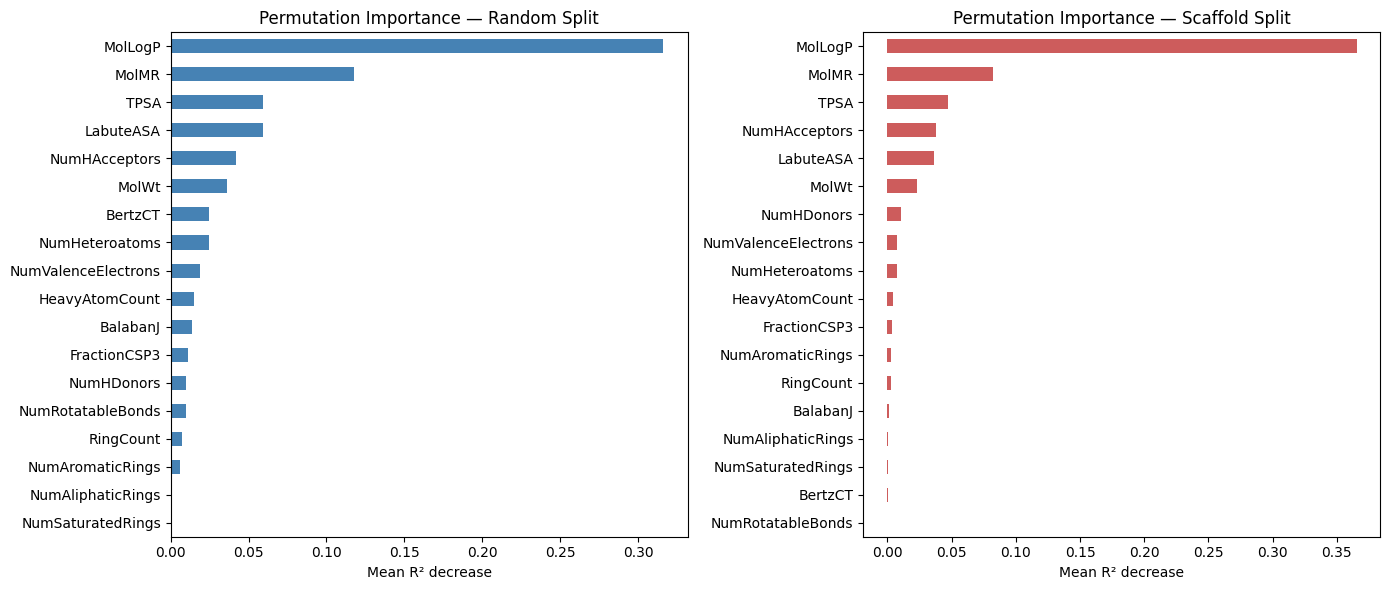


Top-5 features shared between random-split and scaffold-split rankings: 5/5
Shared features: ['LabuteASA', 'MolLogP', 'MolMR', 'NumHAcceptors', 'TPSA']


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False)

perm_importance_random.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Permutation Importance — Random Split")
axes[0].set_xlabel("Mean R² decrease")
axes[0].invert_yaxis()

perm_importance_scaffold.plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title("Permutation Importance — Scaffold Split")
axes[1].set_xlabel("Mean R² decrease")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

top5_random = set(perm_importance_random.head(5).index)
top5_scaffold = set(perm_importance_scaffold.head(5).index)
overlap = top5_random & top5_scaffold
print(f"\nTop-5 features shared between random-split and scaffold-split rankings: {len(overlap)}/5")
print(f"Shared features: {sorted(overlap)}")

In [52]:
# Compare built-in RF importance vs permutation importance (random split)
builtin_vs_perm = pd.DataFrame({
    "Built-in importance": importance.sort_values(ascending=False),
    "Permutation importance": perm_importance_random,
}).round(4)

display(builtin_vs_perm)

,Built-in importance,Permutation importance
BalabanJ,0.0199,0.0138
BertzCT,0.0519,0.0247
FractionCSP3,0.0124,0.0111
HeavyAtomCount,0.0433,0.0147
LabuteASA,0.1021,0.0591
MolLogP,0.2896,0.3160
MolMR,0.1553,0.1178
MolWt,0.0751,0.0363
NumAliphaticRings,0.0023,0.0011
NumAromaticRings,0.0142,0.0058


## Applicability Domain (Tanimoto Similarity)

A QSAR model's predictions are only trustworthy for molecules structurally
similar to what it was trained on. We assess this using Morgan (ECFP4-style,
radius=2) fingerprints and Tanimoto similarity: for each scaffold-split test
compound, we compute its maximum Tanimoto similarity to any training
compound. Test compounds with low maximum similarity are outside the
model's applicability domain (AD) and predictions for them should be
treated with more caution, regardless of what the aggregate R² says.

We use the scaffold split (not random split) for this analysis, since
scaffold split is the realistic "novel chemistry" scenario applicability
domain is meant to guard against.

In [53]:


def get_morgan_fp(smiles, radius=2, fpSize=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=fpSize)
    return morgan_gen.GetFingerprint(mol)

train_fps = [get_morgan_fp(s) for s in train_scaffold_df["Canonical_SMILES"]]
test_fps  = [get_morgan_fp(s) for s in test_scaffold_df["Canonical_SMILES"]]

assert all(fp is not None for fp in train_fps), "Fingerprint generation failed for some training compounds"
assert all(fp is not None for fp in test_fps), "Fingerprint generation failed for some test compounds"

print(f"Training fingerprints: {len(train_fps)}")
print(f"Test fingerprints:     {len(test_fps)}")

Training fingerprints: 985
Test fingerprints:     132


In [54]:
max_similarity = [
    max(DataStructs.BulkTanimotoSimilarity(fp, train_fps))
    for fp in test_fps
]

test_scaffold_df = test_scaffold_df.copy()
test_scaffold_df["max_train_similarity"] = max_similarity

print("Max Tanimoto similarity to nearest training compound, distribution:")
print(test_scaffold_df["max_train_similarity"].describe().round(3))

Max Tanimoto similarity to nearest training compound, distribution:
count    132.000
mean       0.486
std        0.200
min        0.160
25%        0.333
50%        0.477
75%        0.603
max        1.000
Name: max_train_similarity, dtype: float64


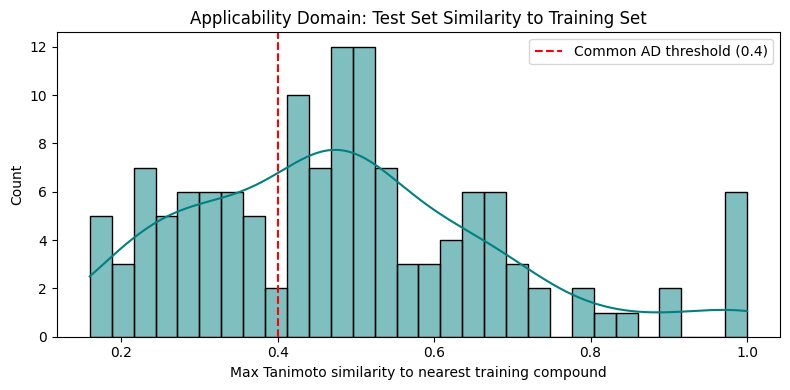


In-domain test compounds (similarity >= 0.4):  87
Out-of-domain test compounds (similarity < 0.4): 45


In [55]:
plt.figure(figsize=(8, 4))
sns.histplot(test_scaffold_df["max_train_similarity"], bins=30, kde=True, color="teal")
plt.axvline(0.4, linestyle="--", color="red", label="Common AD threshold (0.4)")
plt.xlabel("Max Tanimoto similarity to nearest training compound")
plt.ylabel("Count")
plt.title("Applicability Domain: Test Set Similarity to Training Set")
plt.legend()
plt.tight_layout()
plt.show()

# 0.4 Tanimoto (ECFP4) is a commonly cited rule-of-thumb AD cutoff in QSAR literature;
# below this, structural similarity to anything in training is weak.
in_domain = (test_scaffold_df["max_train_similarity"] >= 0.4).sum()
out_domain = (test_scaffold_df["max_train_similarity"] < 0.4).sum()
print(f"\nIn-domain test compounds (similarity >= 0.4):  {in_domain}")
print(f"Out-of-domain test compounds (similarity < 0.4): {out_domain}")

Correlation between max training similarity and absolute error: -0.174
(Negative correlation = compounds farther from training data tend to have larger errors,
 which is the expected AD relationship if it holds for this dataset.)


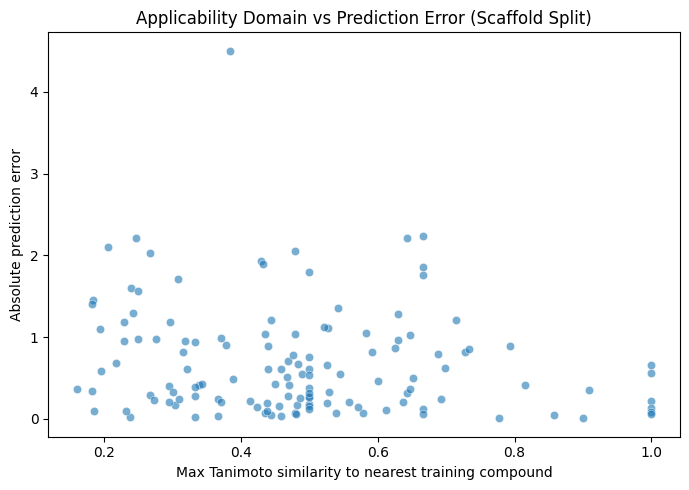

In [56]:
# Does prediction error correlate with applicability domain?
test_scaffold_df["abs_error"] = np.abs(residuals_scaffold.values)

corr_sim_error = test_scaffold_df["max_train_similarity"].corr(test_scaffold_df["abs_error"])
print(f"Correlation between max training similarity and absolute error: {corr_sim_error:.3f}")
print("(Negative correlation = compounds farther from training data tend to have larger errors,")
print(" which is the expected AD relationship if it holds for this dataset.)")

plt.figure(figsize=(7, 5))
sns.scatterplot(
    x=test_scaffold_df["max_train_similarity"],
    y=test_scaffold_df["abs_error"],
    alpha=0.6,
)
plt.xlabel("Max Tanimoto similarity to nearest training compound")
plt.ylabel("Absolute prediction error")
plt.title("Applicability Domain vs Prediction Error (Scaffold Split)")
plt.tight_layout()
plt.show()

## Worst Predictions: Error Analysis

Closing the loop with the applicability domain analysis above: are the
worst-predicted compounds also the ones structurally farthest from
training data?

In [57]:
worst_predictions = (
    test_scaffold_df
    .assign(
        actual=y_test_scaffold.values,
        predicted=y_pred_scaffold,
    )
    .sort_values("abs_error", ascending=False)
    .head(15)
)

display(
    worst_predictions[[
        "compound_name", "actual", "predicted", "abs_error",
        "max_train_similarity", "MolWt", "MolLogP"
    ]].round(3)
)

mean_sim_worst = worst_predictions["max_train_similarity"].mean()
mean_sim_all = test_scaffold_df["max_train_similarity"].mean()
print(f"\nMean training-set similarity, worst 15 predictions: {mean_sim_worst:.3f}")
print(f"Mean training-set similarity, all test compounds:    {mean_sim_all:.3f}")
if mean_sim_worst < mean_sim_all:
    print("\nWorst predictions are, on average, farther from the training set than")
    print("the typical test compound — consistent with an applicability domain effect.")
else:
    print("\nWorst predictions are NOT noticeably farther from the training set than")
    print("average — errors here are likely driven by something other than novelty")
    print("(e.g. descriptor limitations, intrinsic noise in the measured solubility).")

,compound_name,actual,predicted,abs_error,max_train_similarity,MolWt,MolLogP
599,"2,2',3,3',4,4',5,5',6,6'-PCB",-11.600,-7.098,4.502,0.385,498.662,9.888
296,"2,2',3,3',4,4',5,5'-PCB",-9.160,-6.926,2.234,0.667,429.772,8.581
262,TEFLUBENZURON,-7.280,-5.063,2.217,0.246,381.112,4.512
60,"2,2',3,3',5,5',6,6'-PCB",-9.150,-6.939,2.211,0.643,429.772,8.581
21,Lenacil,-4.594,-2.495,2.099,0.206,234.299,1.530
871,"2,2',3,4,5,5',6-PCB",-8.940,-6.888,2.052,0.478,395.327,7.927
548,2-methylpteridine,-0.120,-2.150,2.030,0.267,146.153,0.728
455,Etomidate,-4.735,-2.807,1.928,0.429,244.294,2.669
955,difluron,-6.020,-4.121,1.899,0.432,310.687,3.580
863,"2,2',4,4',6,6'-PCB",-8.710,-6.849,1.861,0.667,360.882,7.274



Mean training-set similarity, worst 15 predictions: 0.425
Mean training-set similarity, all test compounds:    0.486

Worst predictions are, on average, farther from the training set than
the typical test compound — consistent with an applicability domain effect.


## Summary & Limitations

**What this notebook establishes:**
- A cleaned, deduplicated, canonically-validated compound set (ESOL/Delaney, ~1,100 compounds)
- A physically-motivated baseline (logP-only GSE approximation) that Random Forest is
  compared against on both random and scaffold splits
- Scaffold-based evaluation (both single-split and GroupKFold CV) to test generalization
  to structurally novel compounds, not just held-out rows of familiar chemistry
- Permutation importance, computed on held-out data for both split strategies, to check
  whether the model's reasoning is consistent or split-dependent
- An applicability domain analysis (Tanimoto similarity to nearest training compound)
  connecting structural novelty directly to prediction error

**Known limitations:**
- GSE approximation omits the melting-point term (not available in ESOL/Delaney) —
  results should be read as "beats a partial physical baseline," not the full published equation
- Single dataset, single source — no multi-source measurement disagreement to analyze
  (unlike AqSolDB)
- Feature set is RDKit 2D descriptors only; a descriptors-vs-Morgan-fingerprints ablation
  was scoped but deferred as future work
- Applicability domain threshold (Tanimoto 0.4) is a commonly cited rule of thumb, not
  tuned or validated specifically for this dataset